In [1]:
import matplotlib.pyplot as plt
# Data handling
import pandas as pd
import numpy as np

import ast
import html
import re

In [2]:
candidate_df = pd.read_csv("datasets/v1_recipe_dataset.csv")

In [6]:
candidate_df[candidate_df['id'] == 124328]

,Unnamed: 0,id,name,description,ingredients,ingredients_raw,steps,servings,serving_size,tags,...,meal_type_is_beverage,meal_type_is_burger,meal_type_is_curry,meal_type_is_light_meal,season_is_fall,season_is_spring,season_is_summer,season_is_winter,temp_is_served_cold,temp_is_served_hot
19,35,124328,Chicken and Macaroni Casserole,I found this recipe in an old cookbook. You ca...,"[""elbow macaroni"", ""shredded low - fat cheddar...","[""1 1/2 cups uncooked elbow macaroni (about...","[""Heat oven to 350 degrees."", ""Mix all ingredi...",4.0,1 (171 g),"[""time-to-make"", ""course"", ""main-ingredient"", ...",...,0,0,0,0,1,1,0,1,0,0


In [27]:
feature_prefixes = (
    "ingredient_",
    "meal_type_",
    "cuisine_",
    "diet_",
    "cooking_",
    "duration_",
    "complexity_",
    "taste_",
    "season_",
    "taste_"
)

feature_cols = [
    col for col in candidate_df.columns
    if col.startswith(feature_prefixes)
]

feature_matrix = candidate_df[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

candidate_df = candidate_df.copy()
candidate_df["feature_count"] = feature_matrix.sum(axis=1)

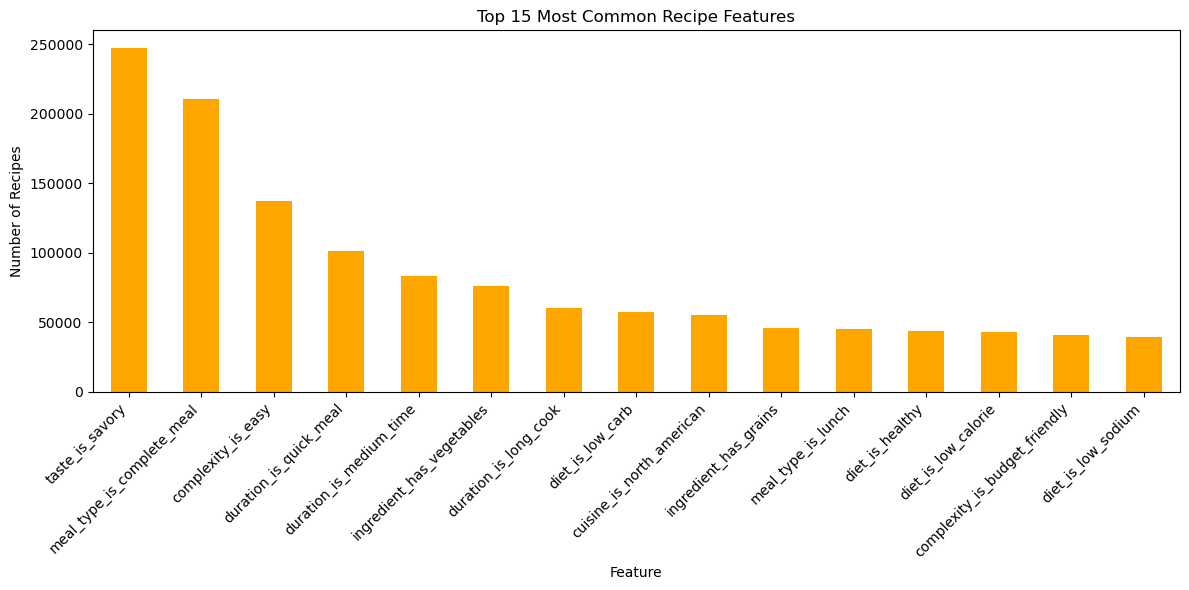

In [30]:
feature_counts = candidate_df[feature_cols].sum()

top_features = feature_counts.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))

top_features.plot(kind="bar", color="orange")

plt.title("Top 15 Most Common Recipe Features")
plt.xlabel("Feature")
plt.ylabel("Number of Recipes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

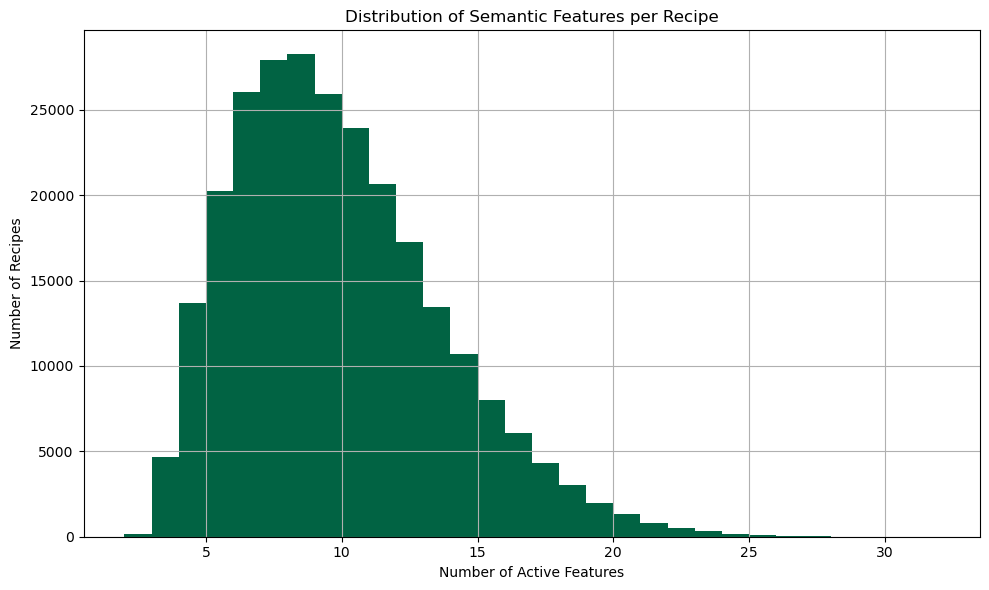

In [42]:
plt.figure(figsize=(10, 6))

candidate_df["feature_count"].hist(bins=30, color="#016343")

plt.title("Distribution of Semantic Features per Recipe")
plt.xlabel("Number of Active Features")
plt.ylabel("Number of Recipes")

plt.tight_layout()
plt.show()

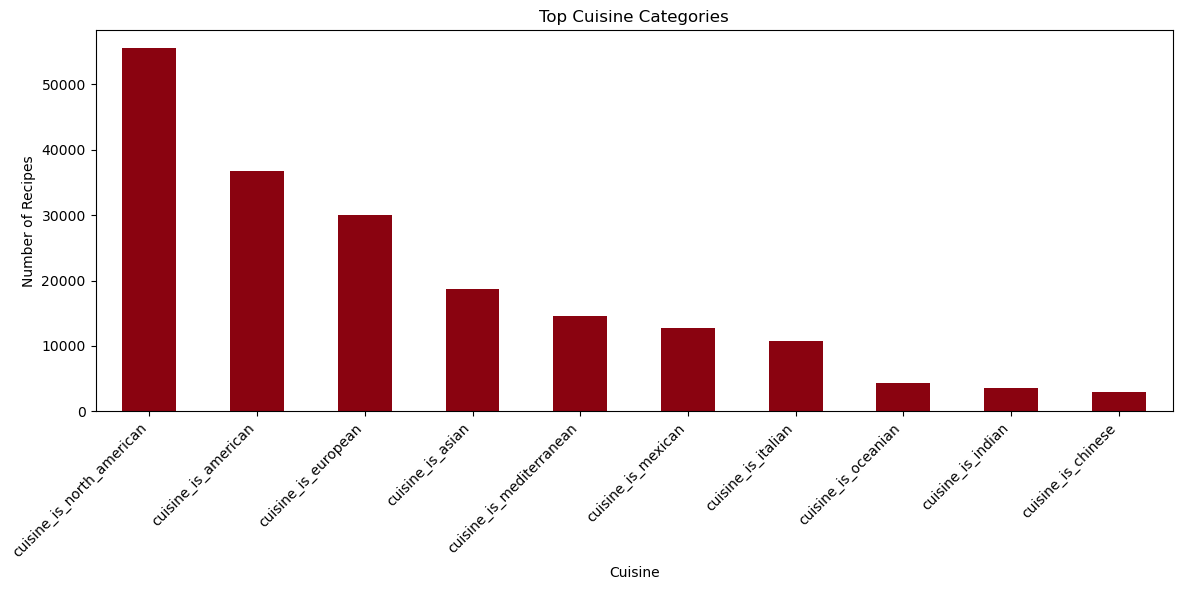

In [40]:
cuisine_cols = [
    col for col in candidate_df.columns
    if col.startswith("cuisine_")
]

cuisine_counts = candidate_df[cuisine_cols].sum()

top_cuisines = cuisine_counts.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

top_cuisines.plot(kind="bar", color="#8a0310")

plt.title("Top Cuisine Categories")
plt.xlabel("Cuisine")
plt.ylabel("Number of Recipes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

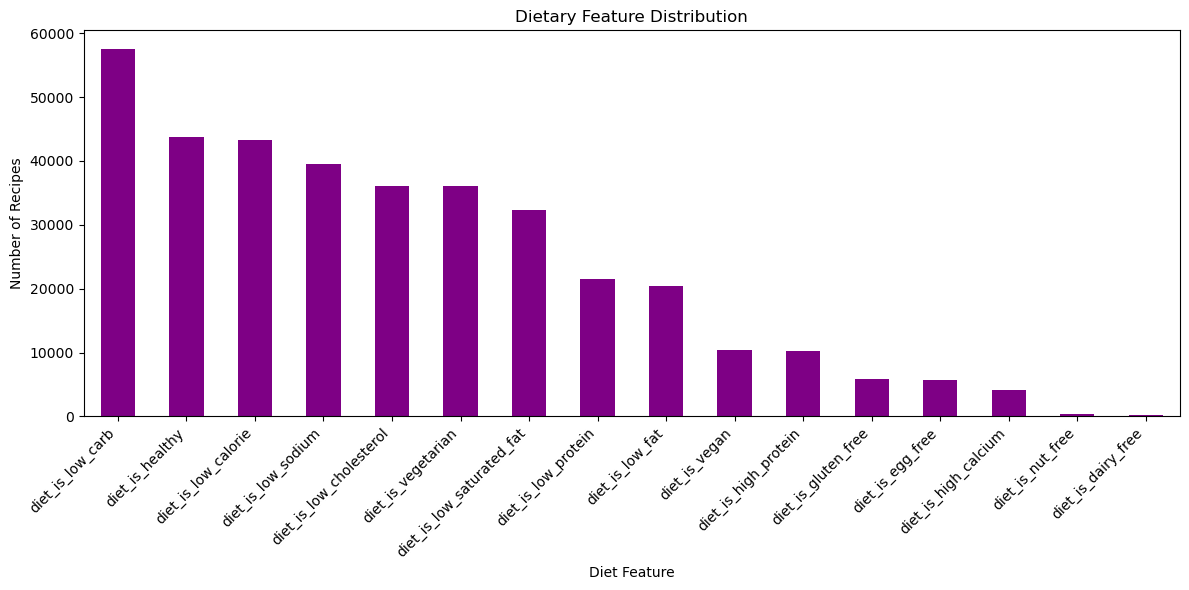

In [44]:
diet_cols = [
    col for col in candidate_df.columns
    if col.startswith("diet_")
]

diet_counts = candidate_df[diet_cols].sum()

diet_counts = diet_counts.sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

diet_counts.plot(kind="bar", color = "#7e0085")

plt.title("Dietary Feature Distribution")
plt.xlabel("Diet Feature")
plt.ylabel("Number of Recipes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()